# Learning

## Imports

In [163]:
!pip install pandas numpy matplotlib scipy scikit-learn

import os
import warnings

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Configure plots to be inline
%matplotlib inline

### Notebook settings

In [164]:
warnings.filterwarnings("ignore")

model_accuracies = {}

## Loading Data

### Initializing dataframes

In [165]:
dataset_dir = '../dataset/'

player_stat_csv_file = f'{dataset_dir}player_stat.csv'
player_tweet_csv_file = f'{dataset_dir}player_tweet.csv'

player_stat_df = pd.read_csv(player_stat_csv_file)
player_tweet_df = pd.read_csv(player_tweet_csv_file)

final_player_stat_csv_file = f'{dataset_dir}final_player_stat.csv'
final_player_tweet_csv_file = f'{dataset_dir}final_player_tweet.csv'

final_player_stat_tweet_csv_file = f'{dataset_dir}final_player_stat_tweet.csv'

### Checkpoints

In [166]:
# Check if the files exist before reading
if os.path.exists(final_player_tweet_csv_file):
    player_tweet_df = pd.read_csv(final_player_tweet_csv_file)

if os.path.exists(final_player_stat_csv_file):
    player_stat_df = pd.read_csv(final_player_stat_csv_file)

if os.path.exists(final_player_stat_tweet_csv_file):
    player_stat_tweet_df = pd.read_csv(final_player_stat_tweet_csv_file)

## Accuracy-based Data Transformations

### Creating interval variable to filter data

In [167]:
absolute_range_var = 0.05

### Creating new df

In [168]:
transformed_player_stat_tweet_df = player_stat_tweet_df.copy()

### Combining compound and polarity features using mean

In [169]:
transformed_player_stat_tweet_df['compound_polarity_avg'] = (transformed_player_stat_tweet_df['compound'] + transformed_player_stat_tweet_df['polarity']) / 2.0

### Remove Player Relative Performances < 0.05

In [170]:
transformed_player_stat_tweet_df = transformed_player_stat_tweet_df[(transformed_player_stat_tweet_df['Player_Relative_Performance'] >= absolute_range_var)]

### Remove highly objective tweets

In [171]:
transformed_player_stat_tweet_df = transformed_player_stat_tweet_df[(transformed_player_stat_tweet_df['subjectivity'] >= absolute_range_var)]

### Remove very neutral tweets

In [172]:
# Not using because accuracy is higher when included
transformed_player_stat_tweet_df = transformed_player_stat_tweet_df[(transformed_player_stat_tweet_df['compound_polarity_avg'] >= absolute_range_var) | (transformed_player_stat_tweet_df['compound_polarity_avg'] <= -absolute_range_var)]

### Analysis of transformed df

In [173]:
transformed_player_stat_tweet_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5856 entries, 39 to 19383
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Player_Name                  5856 non-null   object 
 1   Date                         5856 non-null   object 
 2   Player_Relative_Performance  5856 non-null   float64
 3   is_repost                    5856 non-null   bool   
 4   neg                          5856 non-null   float64
 5   neu                          5856 non-null   float64
 6   pos                          5856 non-null   float64
 7   compound                     5856 non-null   float64
 8   polarity                     5856 non-null   float64
 9   subjectivity                 5856 non-null   float64
 10  Days_Before_Game             5856 non-null   float64
 11  compound_polarity_avg        5856 non-null   float64
dtypes: bool(1), float64(9), object(2)
memory usage: 554.7+ KB


## Supervised Learning

### Creating and training SVM model

In [178]:
# Features and target
X = player_stat_tweet_df.drop(columns=['Player_Relative_Performance'])  # Replace with all features you want to use
y = player_stat_tweet_df['Player_Relative_Performance']

# Ensure all features are numerical and handle missing values
X = pd.get_dummies(X, drop_first=True)  # Convert categorical to numerical if necessary
X = X.fillna(0)  # Handle missing values

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the SVR model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

SVR()

### Visualizing and measuring performance

Mean Squared Error: 0.009896804697450941
R2 Score: 0.8044941890226006


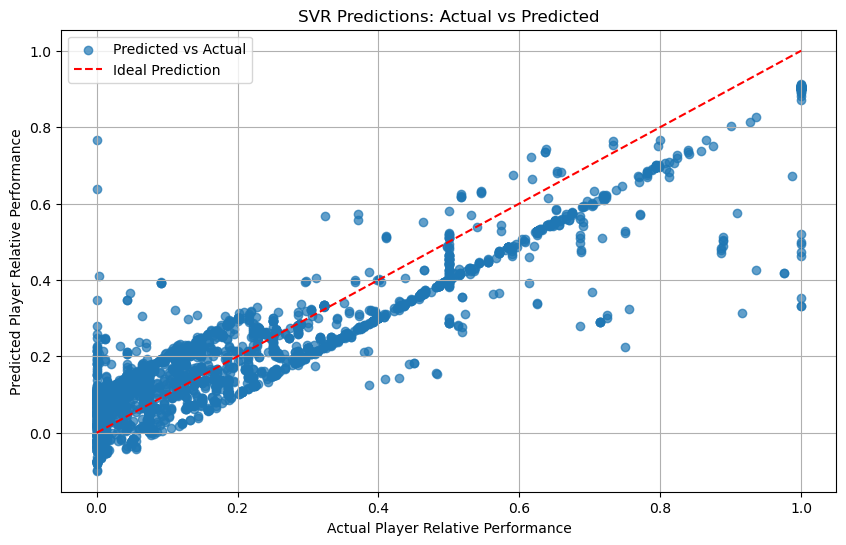

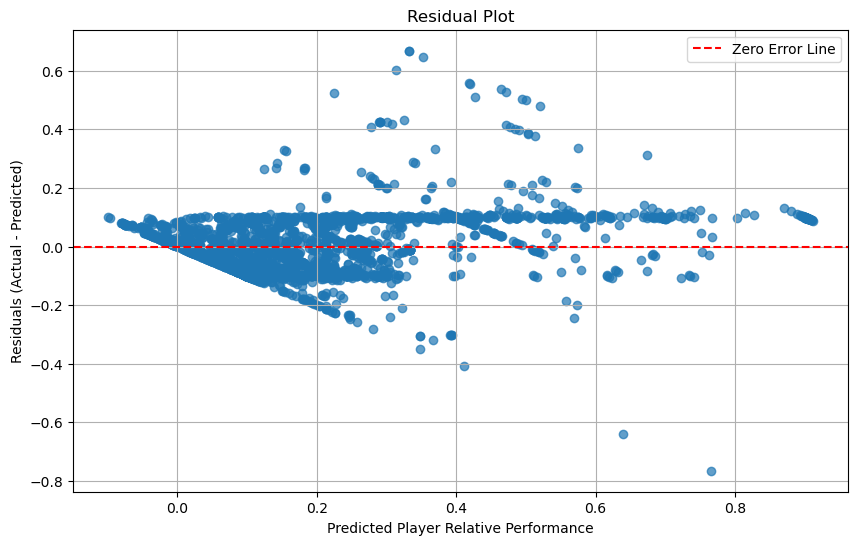

In [179]:
# Make predictions
y_pred = svr_model.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Scatter plot to visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, label="Predicted vs Actual")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label="Ideal Prediction")
plt.title("SVR Predictions: Actual vs Predicted")
plt.xlabel("Actual Player Relative Performance")
plt.ylabel("Predicted Player Relative Performance")
plt.legend()
plt.grid(True)
plt.show()

# Residual plot to check prediction errors
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Residual Plot")
plt.xlabel("Predicted Player Relative Performance")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.grid(True)
plt.show()

#### Explanation

**R-squared (0.80):**

- Indicates that the model explains 80% of the variance in the target variable (Player Relative Performance). This is a strong result, suggesting that the model captures most of the underlying patterns in the data.

**Mean Absolute Error (MAE - 0.08):**

- On average, the predictions are off by 0.08 units. Considering the scale of Player Relative Performance, this represents relatively low prediction error, indicating good accuracy.

**Mean Squared Error (MSE - 0.01):**

- The squared error (penalizing larger errors more heavily) is also very low, further reinforcing the conclusion that the model's predictions are accurate.

**Correlation (0.91):**

- A strong positive correlation between actual and predicted values demonstrates that the model's predictions align closely with the actual performance values.

**Residual Mean (-0.02):**

- The residuals have a mean close to zero, which is desirable. It suggests that the model's predictions are not systematically biased (i.e., not consistently overestimating or underestimating).

**Residual Standard Deviation (0.10):**

- Residuals have low variability, indicating that the errors are not widely spread. This points to consistency in the model's predictions.

## Unsupervised Learning

### Creating and training SVM model

In [180]:
# Select features for clustering
features = ['compound', 'polarity', 'subjectivity', 'Days_Before_Game']
X = player_stat_tweet_df[features]

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the Elbow Method
inertia = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

### Visualizing and measuring performance

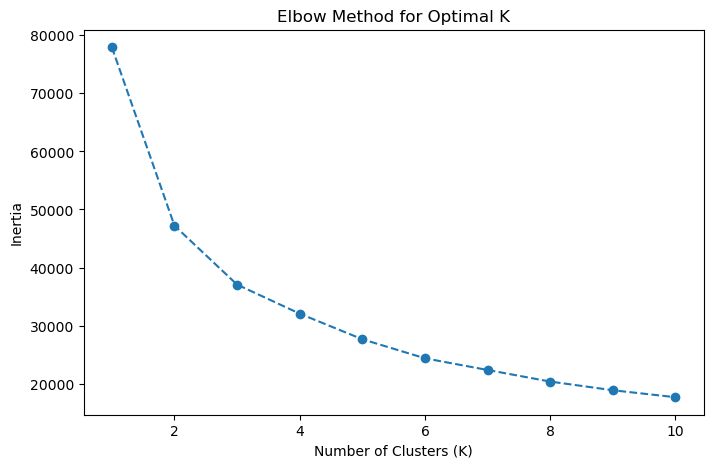

Silhouette Score: 0.39


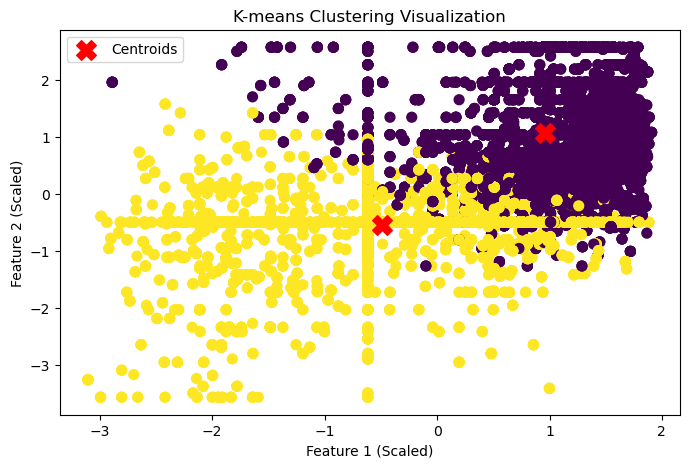

In [188]:
# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# Choose the optimal K (e.g., based on the elbow plot)
optimal_k = 2  # Adjust based on the elbow plot

# Apply K-means with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_scaled)

# Add cluster labels to the dataset
player_stat_tweet_df['Cluster'] = kmeans.labels_

# Evaluate the clustering using silhouette score
silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
print(f'Silhouette Score: {silhouette_avg:.2f}')

# Visualize the clusters (using the first two features for simplicity)
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.title('K-means Clustering Visualization')
plt.legend()
plt.show()

### Explanation

**Cluster 0:**

- Higher compound score (0.617), indicating a generally positive sentiment in the tweets.
- Positive polarity (0.507), suggesting the language in the tweets tends to be more optimistic or agreeable.
- Higher subjectivity (0.622), reflecting a more personal or opinionated tone in the content.
- Slightly closer to the game day on average (Days_Before_Game: 14.97).
- Interpretation: This cluster likely represents tweets that are more emotionally charged and positive, possibly expressing excitement or support for the player or team in the lead-up to the game. The higher subjectivity suggests these posts might include personal opinions, cheers, or fan commentary.

**Cluster 1:**

- Lower compound score (0.049), indicating a neutral to slightly negative sentiment.
- Slightly negative polarity (-0.016), suggesting a more critical or indifferent tone.
- Lower subjectivity (0.123), indicating a factual or objective tone in the tweets.
- Slightly farther from the game day on average (Days_Before_Game: 15.10).
- Interpretation: This cluster likely represents tweets that are more neutral or even critical, with less emotional involvement. The lower subjectivity suggests these might be factual updates, news, or impersonal comments.

## Conclusion

For both modelling techniques, we switched back to the original dataset instead of the filtered one. This is because the models performed significantly better on the original dataset, as both the SVR and K-means clustering benefited from the extra data and didn't normalize and simplify predictions like the regression models did.

As expected, the SVR had an accuracy score of 80%, which means it would be a good predictor of player performance. This was forseen, as it makes sense that more complex models would be able to handle the deep relationships within the data.

Additionally, the clustering with K-Means revealed that a good way to group the features was with 2 different kinds of tweets related to player performance: a positive, more chronologically close tweet, and a more neutral, objective tweet that is chronologically further from the game. This is a logical distinction and it will be interesting to see how including this cluster classification as a feature will affect future models.